# Importando Bibliotecas

### Imports Gerais

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Imports modelos

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

### Carregando o dataset

In [3]:
df = pd.read_csv('data/movies.csv')
df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### Explorando os dados

In [4]:
print ('Temos uma quantidade {} linhas e {} colunas, presente nesse dataset.'
       .format((len (df.index)), df.columns.shape[0]))
print ('Quantidade de dados em cada coluna:')
df.count()

Temos uma quantidade 9742 linhas e 3 colunas, presente nesse dataset.
Quantidade de dados em cada coluna:


movieId    9742
title      9742
genres     9742
dtype: int64

In [5]:
print ('Formato de cada coluna presente no dataset:')
df.dtypes

Formato de cada coluna presente no dataset:


movieId     int64
title      object
genres     object
dtype: object

In [6]:
print ('Quantidade de dados nulos:')
df.isnull().sum()

Quantidade de dados nulos:


movieId    0
title      0
genres     0
dtype: int64

### Dicionario dos dados

**filme_id:** Identificação do filme.

**title:** Titulo do filme e ano de lançamento.

**genres:** Generos atribuidos ao filme.

**Obs:** Conforme visualizado no dataset, vemos que os filmes possuem mais de uma atribuição de gênero. Para melhor análise e aplicação de modelos irei transforma-los em variaveis numericas.

### Tranformando a coluna generos em Dummies

In [7]:
gen = df.genres.str.get_dummies()
data_movies = pd.concat([df, gen], axis=1)
data_movies.head()

,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
data_movies.nunique()

movieId               9742
title                 9737
genres                 951
(no genres listed)       2
Action                   2
Adventure                2
Animation                2
Children                 2
Comedy                   2
Crime                    2
Documentary              2
Drama                    2
Fantasy                  2
Film-Noir                2
Horror                   2
IMAX                     2
Musical                  2
Mystery                  2
Romance                  2
Sci-Fi                   2
Thriller                 2
War                      2
Western                  2
dtype: int64

In [8]:
#Escalando os dados para padronização, removendo a média e dimensionando para a variação da unidade
scaler = StandardScaler()
gen_scale = scaler.fit_transform(gen)
gen_scale

array([[-0.05917995, -0.48060698,  2.59101927, ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698,  2.59101927, ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       ...,
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995,  2.0807022 , -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534],
       [-0.05917995, -0.48060698, -0.3859485 , ..., -0.49125897,
        -0.20201972, -0.13206534]])

### Usando modelo K-means.

In [9]:
modelo = KMeans(n_clusters=3)
modelo.fit(gen_scale)
print(f'Grupos {modelo.labels_}')

Grupos [0 0 2 ... 1 0 2]


In [10]:
print(gen.columns)
print(modelo.cluster_centers_)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')
[[-0.05917995 -0.02656885  0.87126938  2.29169815  2.46865187  0.21479662
  -0.31749856 -0.20242558 -0.58569198  0.85083589 -0.09492563 -0.26812833
   0.2348317   0.37318959 -0.1258928  -0.26232303  0.12316816 -0.46754509
  -0.17515824 -0.08386466]
 [-0.05917995  0.28316836  0.02381864 -0.24468307 -0.26876809 -0.69974775
   0.23350697 -0.21442555  0.30553223 -0.07117629  0.09895263  0.25171046
   0.03950825 -0.18259102  0.20703456 -0.31885886  0.18240479  0.49697064
   0.13889945  0.00845438]
 [ 0.08254352 -0.32194181 -0.23300202 -0.25665139 -0.27045122  0.76040332
  -0.1957975   0.29624941 -0.21605355 -0.11808147 -0.09231268 -0.22853484
  -0.10115167  0.12365482 -0.21028436  0.43141281 -0.24045153 -0.46579175
 

In [11]:
grupos = pd.DataFrame(modelo.cluster_centers_, columns=gen.columns)
grupos

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,-0.059180,-0.026569,0.871269,2.291698,2.468652,0.214797,-0.317499,-0.202426,-0.585692,0.850836,-0.094926,-0.268128,0.234832,0.373190,-0.125893,-0.262323,0.123168,-0.467545,-0.175158,-0.083865
1,-0.059180,0.283168,0.023819,-0.244683,-0.268768,-0.699748,0.233507,-0.214426,0.305532,-0.071176,0.098953,0.251710,0.039508,-0.182591,0.207035,-0.318859,0.182405,0.496971,0.138899,0.008454
2,0.082544,-0.321942,-0.233002,-0.256651,-0.270451,0.760403,-0.195798,0.296249,-0.216054,-0.118081,-0.092313,-0.228535,-0.101152,0.123655,-0.210284,0.431413,-0.240452,-0.465792,-0.119699,0.009971


array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>], dtype=object)

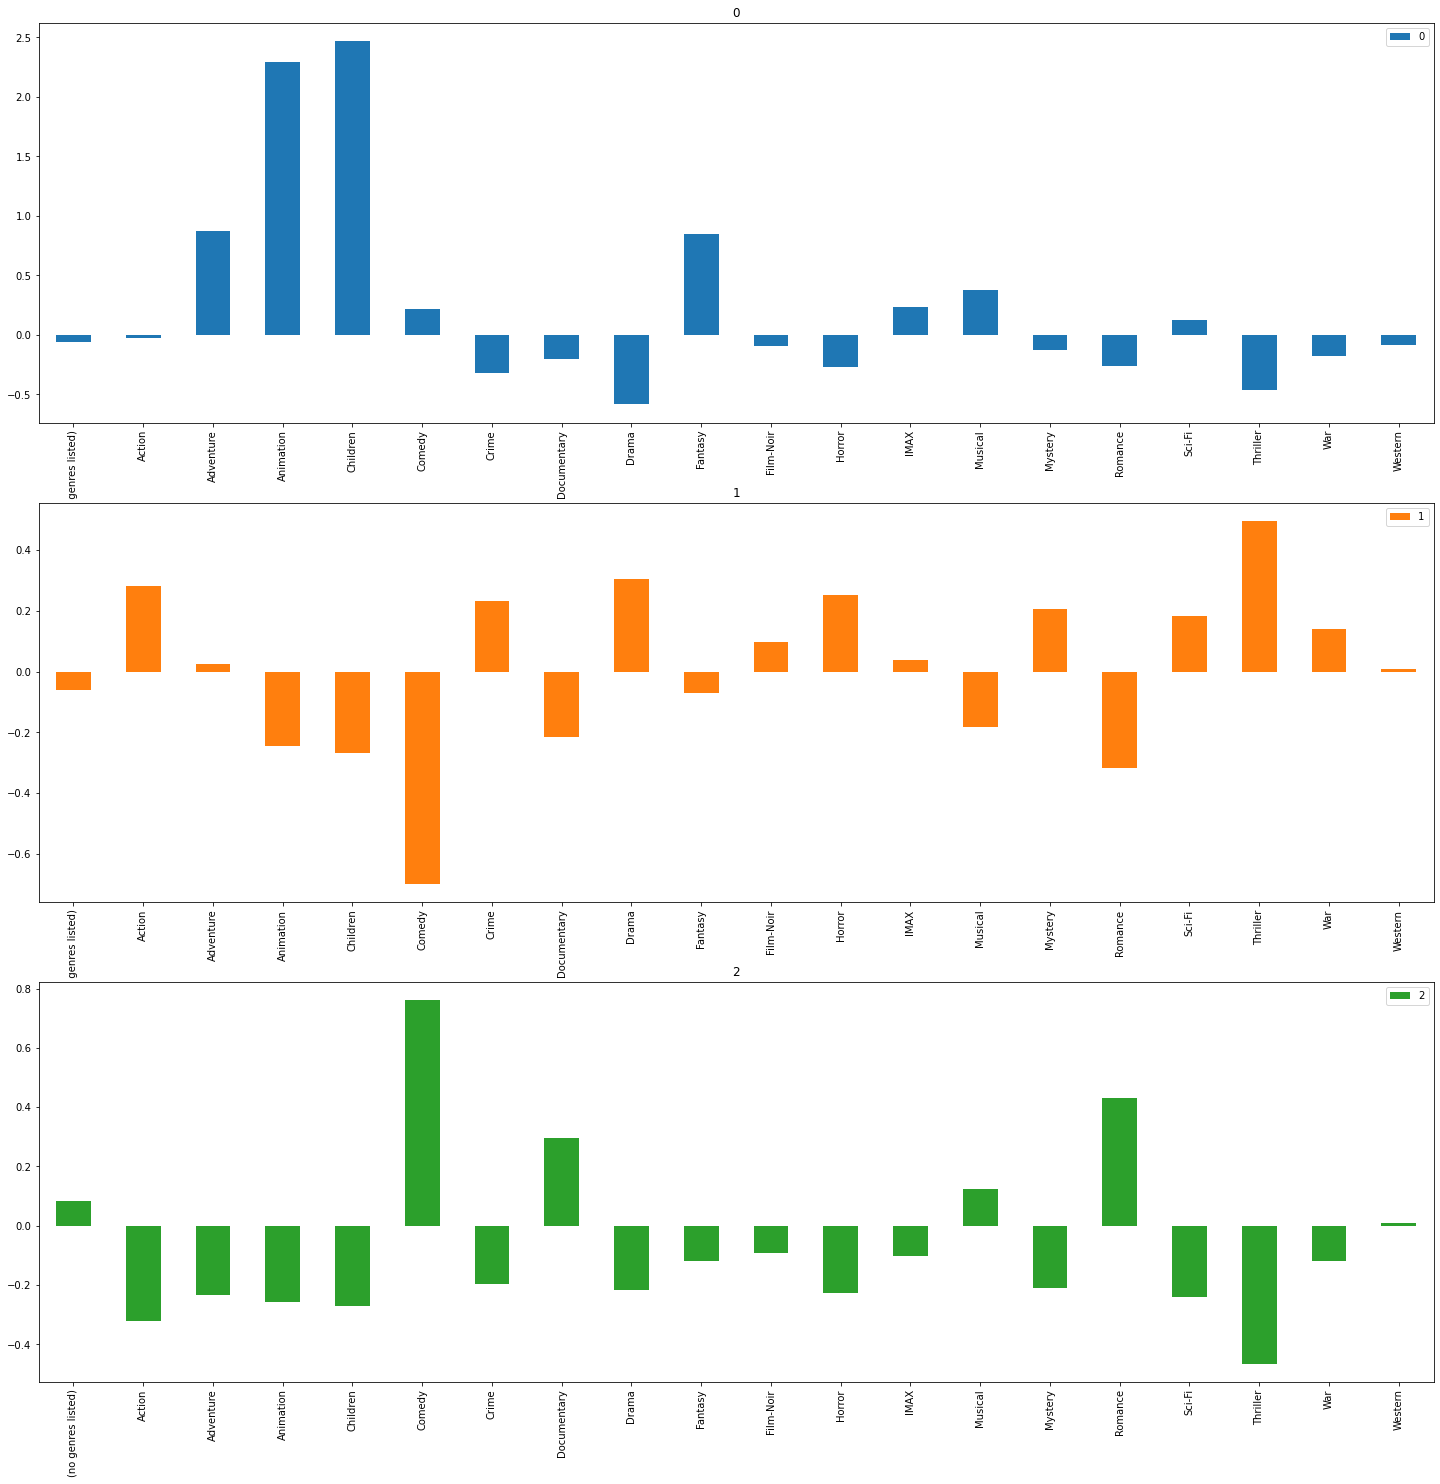

In [12]:
grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 25),
               sharex=False)

In [14]:
print(gen.columns)
print(modelo.cluster_centers_)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='object')
[[-0.05917995 -0.02656885  0.87126938  2.29169815  2.46865187  0.21479662
  -0.31749856 -0.20242558 -0.58569198  0.85083589 -0.09492563 -0.26812833
   0.2348317   0.37318959 -0.1258928  -0.26232303  0.12316816 -0.46754509
  -0.17515824 -0.08386466]
 [-0.05917995  0.28316836  0.02381864 -0.24468307 -0.26876809 -0.69974775
   0.23350697 -0.21442555  0.30553223 -0.07117629  0.09895263  0.25171046
   0.03950825 -0.18259102  0.20703456 -0.31885886  0.18240479  0.49697064
   0.13889945  0.00845438]
 [ 0.08254352 -0.32194181 -0.23300202 -0.25665139 -0.27045122  0.76040332
  -0.1957975   0.29624941 -0.21605355 -0.11808147 -0.09231268 -0.22853484
  -0.10115167  0.12365482 -0.21028436  0.43141281 -0.24045153 -0.46579175
 

In [16]:
grupos = pd.DataFrame(modelo.cluster_centers_, columns=gen.columns)
grupos

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,-0.059180,-0.026569,0.871269,2.291698,2.468652,0.214797,-0.317499,-0.202426,-0.585692,0.850836,-0.094926,-0.268128,0.234832,0.373190,-0.125893,-0.262323,0.123168,-0.467545,-0.175158,-0.083865
1,-0.059180,0.283168,0.023819,-0.244683,-0.268768,-0.699748,0.233507,-0.214426,0.305532,-0.071176,0.098953,0.251710,0.039508,-0.182591,0.207035,-0.318859,0.182405,0.496971,0.138899,0.008454
2,0.082544,-0.321942,-0.233002,-0.256651,-0.270451,0.760403,-0.195798,0.296249,-0.216054,-0.118081,-0.092313,-0.228535,-0.101152,0.123655,-0.210284,0.431413,-0.240452,-0.465792,-0.119699,0.009971


In [18]:
grupo = 0
filtro = modelo.labels_ == grupo
data_movies[filtro].sample(10)

,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
4841,7228,Cool World (1992),Animation|Comedy|Fantasy,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3286,4446,Final Fantasy: The Spirits Within (2001),Adventure|Animation|Fantasy|Sci-Fi,0,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2537,3397,"Great Muppet Caper, The (1981)",Children|Comedy,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1564,2102,Steamboat Willie (1928),Animation|Children|Comedy|Musical,0,0,0,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
9116,145491,Our Lips Are Sealed (2000),Children|Comedy|Drama,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
8593,117545,Asterix: The Land of the Gods (Astérix: Le dom...,Animation,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
870,1151,Lesson Faust (1994),Animation|Comedy|Drama|Fantasy,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
9453,167772,The Spirit of Christmas (1995),Animation|Comedy,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4105,5882,Treasure Planet (2002),Adventure|Animation|Children|Sci-Fi|IMAX,0,0,1,1,1,0,0,...,0,0,1,0,0,0,1,0,0,0
5646,27441,Blood: The Last Vampire (2000),Action|Animation|Horror,0,1,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [22]:
tsne = TSNE()

vis = tsne.fit_transform(gen_scale)
vis

C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DionizVF\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


array([[ 23.5366  ,  62.183334],
       [ 35.5235  ,  53.654392],
       [ -4.254247, -19.119864],
       ...,
       [-33.731113,   8.135662],
       [ 14.831911,  38.95885 ],
       [ 14.603593,  11.274416]], dtype=float32)

In [24]:
def kmeans(numero_de_clusters, generos):
  modelo = KMeans(n_clusters=numero_de_clusters)
  modelo.fit(generos)
  return [numero_de_clusters, modelo.inertia_]

In [27]:
kmeans(20, gen_scale)

[20, 54975.63840295702]

In [29]:
resultado = [kmeans(numero_de_grupos, gen_scale) for numero_de_grupos in range(1, 41)]
resultado

[[1, 194840.00000000274],
 [2, 180457.12596233698],
 [3, 166085.59628047494],
 [4, 156149.28381574142],
 [5, 147884.85436712945],
 [6, 137566.50239636804],
 [7, 128320.6836315318],
 [8, 119521.43186184781],
 [9, 109303.01771337501],
 [10, 103031.57992736541],
 [11, 95172.41279545317],
 [12, 85041.52033412865],
 [13, 79088.7388084363],
 [14, 74998.00849013579],
 [15, 68163.5979654935],
 [16, 63101.14763904947],
 [17, 61547.53602517661],
 [18, 59354.60434503587],
 [19, 56954.147065100406],
 [20, 55934.33279804189],
 [21, 53242.830145220774],
 [22, 52452.42388983595],
 [23, 49897.52420467878],
 [24, 49377.68149244233],
 [25, 48105.02127255815],
 [26, 47927.089867721596],
 [27, 45719.10044907162],
 [28, 44676.759149401354],
 [29, 44007.877930101255],
 [30, 43586.38774486553],
 [31, 42343.39399243591],
 [32, 40844.3003408877],
 [33, 40036.97993736214],
 [34, 39839.80493989581],
 [35, 38694.128886504885],
 [36, 37659.389555927686],
 [37, 37116.81908420454],
 [38, 37084.010090190975],
 [39, 3

In [31]:
resultado = pd.DataFrame(resultado, 
            columns=['grupos', 'inertia'])
resultado

,grupos,inertia
0,1,194840.000000
1,2,180457.125962
2,3,166085.596280
3,4,156149.283816
4,5,147884.854367
5,6,137566.502396
6,7,128320.683632
7,8,119521.431862
8,9,109303.017713
9,10,103031.579927


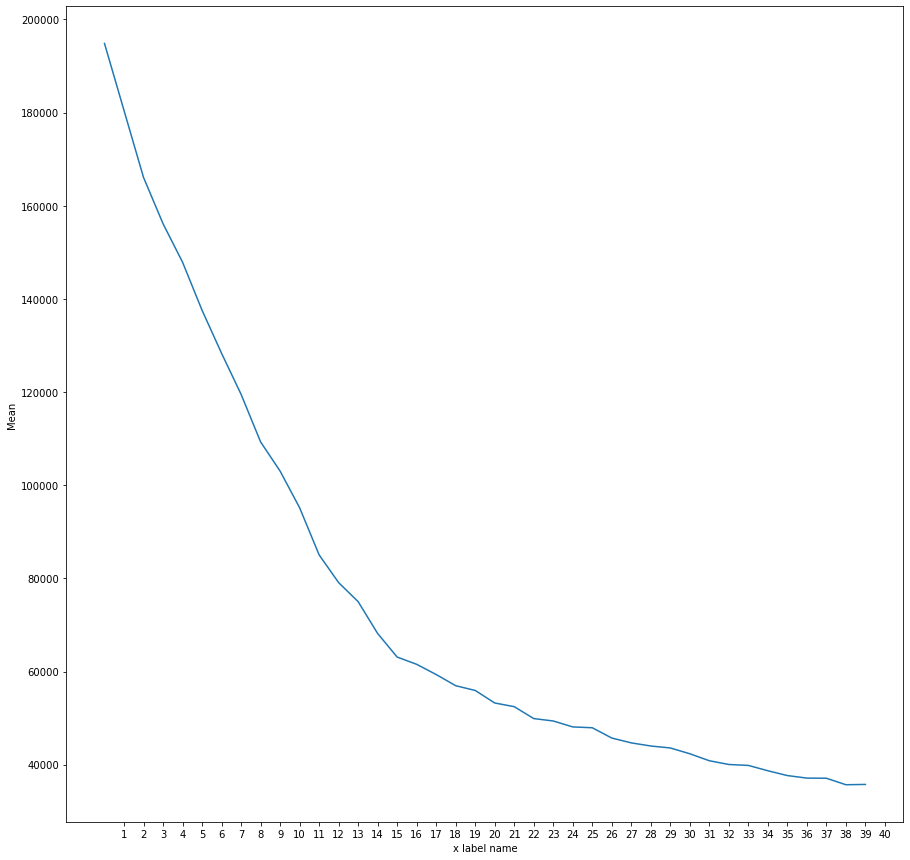

In [51]:
plt.figure(figsize=(15,15))
fig,ax = plt.subplot,(1)
ax = resultado.inertia.plot(kind='line', xticks=resultado.grupos)
ax.set_xlabel('x label name')  
ax.set_ylabel('Mean')
plt.show()

array([<AxesSubplot:title={'center':'0'}>,
       <AxesSubplot:title={'center':'1'}>,
       <AxesSubplot:title={'center':'2'}>,
       <AxesSubplot:title={'center':'3'}>,
       <AxesSubplot:title={'center':'4'}>,
       <AxesSubplot:title={'center':'5'}>,
       <AxesSubplot:title={'center':'6'}>,
       <AxesSubplot:title={'center':'7'}>,
       <AxesSubplot:title={'center':'8'}>,
       <AxesSubplot:title={'center':'9'}>,
       <AxesSubplot:title={'center':'10'}>,
       <AxesSubplot:title={'center':'11'}>,
       <AxesSubplot:title={'center':'12'}>,
       <AxesSubplot:title={'center':'13'}>,
       <AxesSubplot:title={'center':'14'}>,
       <AxesSubplot:title={'center':'15'}>], dtype=object)

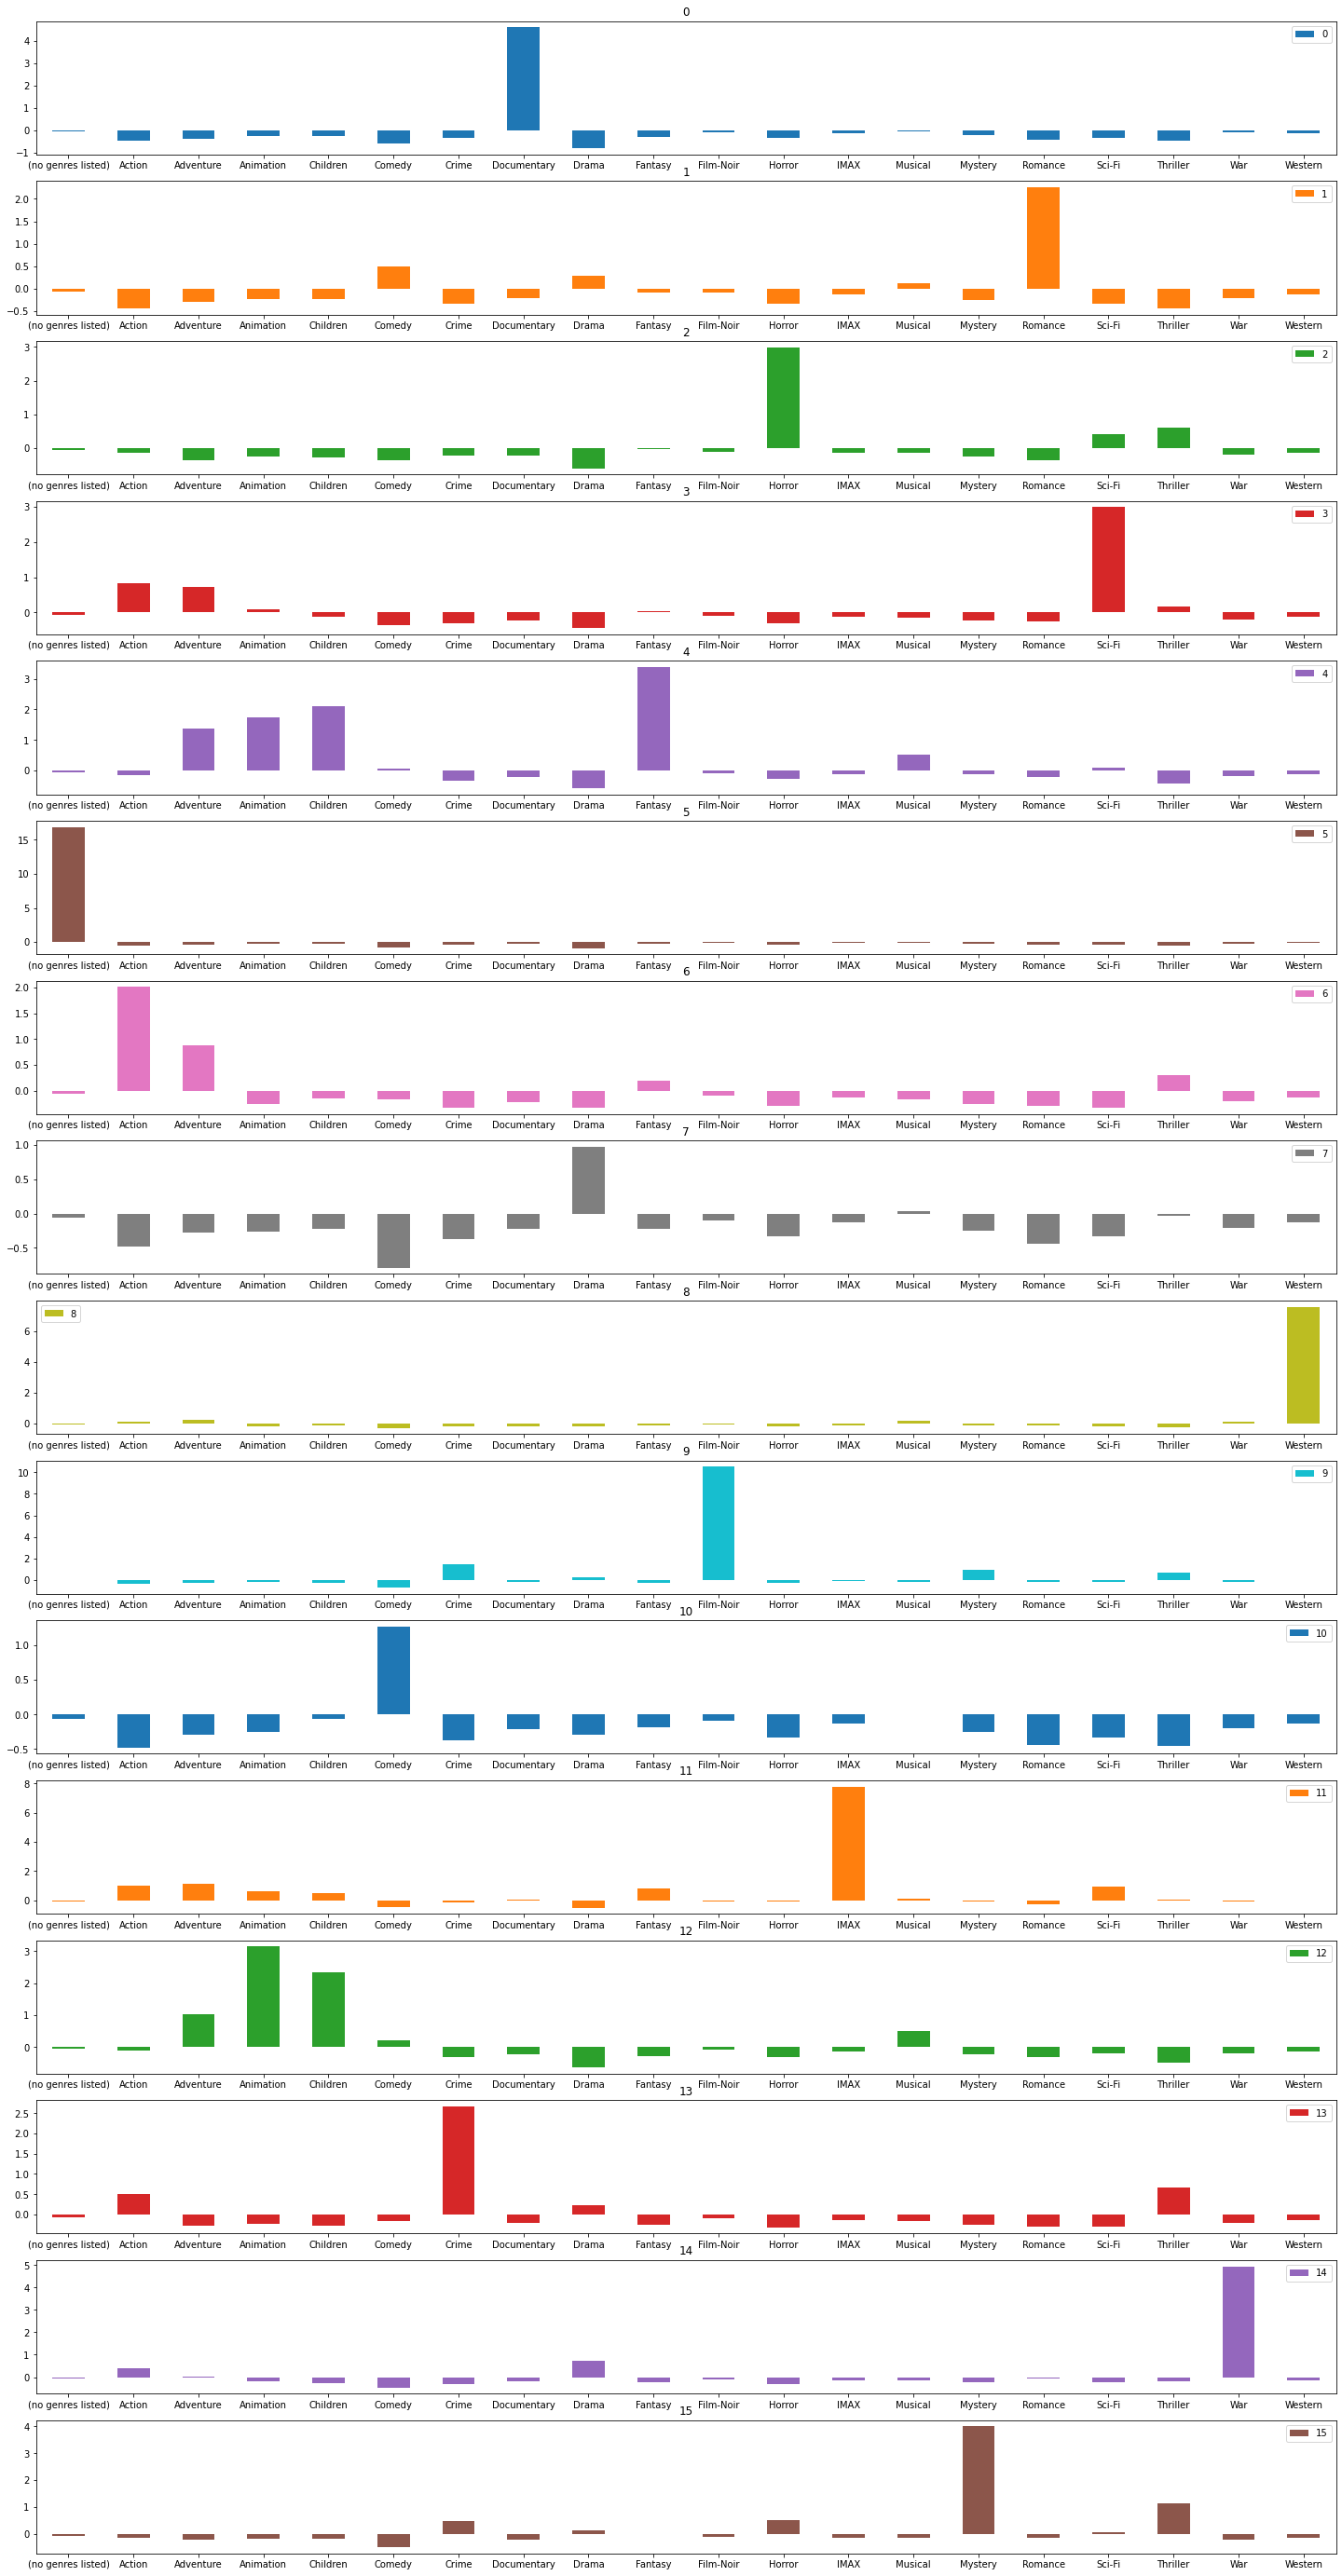

In [61]:
modelo = KMeans(n_clusters=16)
modelo.fit(gen_scale)

grupos = pd.DataFrame(modelo.cluster_centers_,
            columns=gen.columns, )

grupos.transpose().plot.bar(subplots=True,
               figsize=(25, 50),
               sharex=False,
               rot=0)

In [63]:
grupo = 4
filtro = modelo.labels_ == grupo
data_movies[filtro].sample(10)

,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6944,65261,Ponyo (Gake no ue no Ponyo) (2008),Adventure|Animation|Children|Fantasy,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1480,2005,"Goonies, The (1985)",Action|Adventure|Children|Comedy|Fantasy,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
7184,72356,Partly Cloudy (2009),Animation|Children|Comedy|Fantasy,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1444,1967,Labyrinth (1986),Adventure|Fantasy|Musical,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9457,168090,Kizumonogatari II: Passionate Blood (2016),Animation|Fantasy|Mystery,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4874,7304,Allegro non troppo (1977),Animation|Comedy|Fantasy|Musical,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
5546,26662,Kiki's Delivery Service (Majo no takkyûbin) (1...,Adventure|Animation|Children|Drama|Fantasy,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9372,162600,Miss Peregrine's Home for Peculiar Children (2...,Fantasy,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
